In [1]:
library(tidyverse)
library(ggpubr)
library(readr)
library(biomformat)
library(cowplot)
library(pROC)  
library(scales)
library(ggrepel)
library(patchwork)
library(ggpubr) 
library(ggsci)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.2.0
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.3     v tibble    3.3.1
v lubridate 1.9.5     v tidyr     1.3.2
v purrr     1.2.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'cowplot'


The following object is masked from 'package:ggpubr':

    get_legend


The following object is masked from 'package:lubridate':

    stamp


Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var



Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':



### The correlation between SNE similarity and phylogenetic distance

In [2]:
table_group <- read.csv("data/tax_group.csv")
table_group$tax <- factor(table_group$tax, levels = c("Phylum", "Class", "Order", "Family", "Genus"), ordered = TRUE)


table_group <- table_group %>%
    group_by(tax) %>%
    mutate(
        r = cor(embed_cosine_mean, phy_dist_mean), # Pearson 
        slope = lm(phy_dist_mean ~ embed_cosine_mean)$coefficients[2], 
        intercept = lm(phy_dist_mean ~ embed_cosine_mean)$coefficients[1] 
    )
    
p1 <- ggplot(table_group, aes(x = embed_cosine_mean, y = phy_dist_mean)) +

    geom_errorbar(aes(ymin = phy_dist_mean - phy_dist_sd, ymax = phy_dist_mean + phy_dist_sd),
                  width = 0.02, color = "gray", linewidth = 0.3
    ) +
    geom_errorbarh(aes(xmin = embed_cosine_mean - embed_cosine_sd, xmax = embed_cosine_mean + embed_cosine_sd),
                   height = 0.02, color = "gray", linewidth = 0.3
    ) +
    geom_point(size = 2, alpha = 0.4, color = "blue") +
    geom_abline(aes(slope = slope, intercept = intercept), color = "red", linetype = "dashed", linewidth = 0.8) +
    geom_text(aes(x = 0.2, y = 1.5, label = paste0("r = ", round(r, 2))), size = 4, color = "black") +

    facet_wrap(~tax, nrow = 1) +

    labs(
        x = "SNE cosine",
        y = "Phylo distance",
        title = ""
    ) +

    theme_bw() +
    theme(
        legend.position = "top",
        plot.title = element_text(hjust = 0.5),
    )

Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
i Please use the `orientation` argument of `geom_errorbar()` instead."


`height` was translated to `width`.


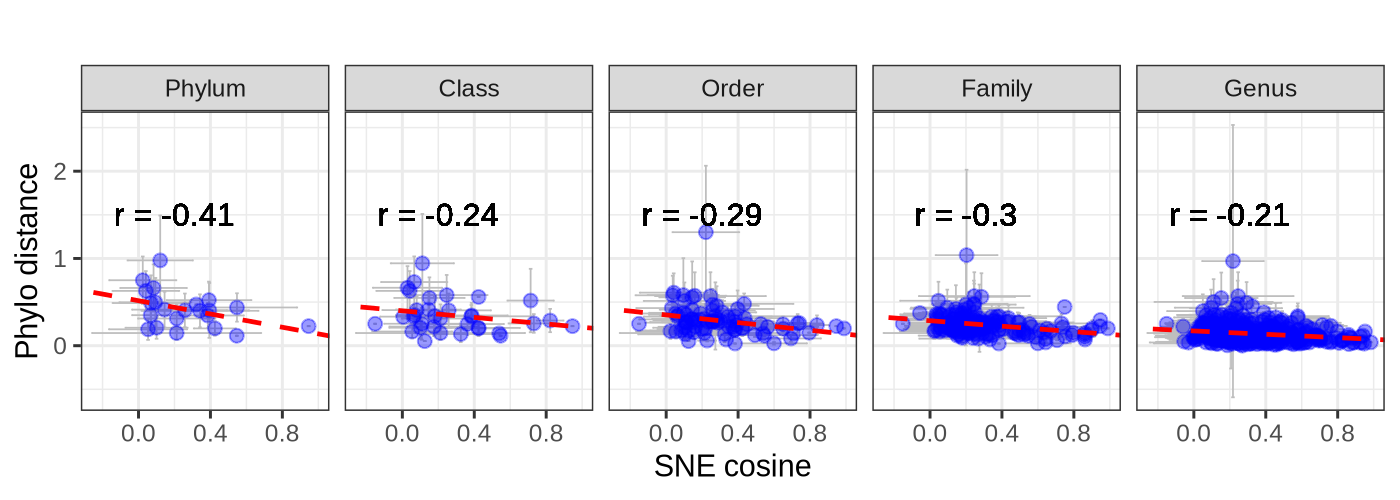

In [3]:
local({
  options(repr.plot.width = 7, repr.plot.height = 2.5, repr.plot.res = 200)
  print(p1)
})

### The HGT frequency

In [4]:
hgt_plot_res <- read.csv("data/hgt_plot_res.csv")
hgt_plot_res$distance[hgt_plot_res$group == "SNE"] <- 1 - hgt_plot_res$distance[hgt_plot_res$group == "SNE"]

df <- hgt_plot_res %>% filter(group == "Phylo")
summary(lm(hgt_rate ~ distance, df))

phylogeny_data <- hgt_plot_res %>% filter(group != "SNE")
x_primary_range <- range(phylogeny_data$distance)

coembed_data <- hgt_plot_res %>% filter(group == "SNE") %>% 
    mutate(scaled_x = rescale(distance, to = x_primary_range))

coembed_data$scaled_x <- rescale(coembed_data$distance, 
                                 to = range(phylogeny_data$distance))
primary_range <- range(phylogeny_data$distance)
secondary_range <- range(1 - coembed_data$distance) 
phylogeny_data$group <- factor(phylogeny_data$group, levels = c("Phylo", "Phylo SNEsim > 0.6", "Phylo SNEsim < 0.6"))
Phylo_paired <- phylogeny_data %>%
    dplyr::filter(group != "Phylo")

group1_data <- Phylo_paired$hgt_rate[Phylo_paired$group == "Phylo SNEsim > 0.6"]
group2_data <- Phylo_paired$hgt_rate[Phylo_paired$group == "Phylo SNEsim < 0.6"]

paired_test_res <- t.test(group2_data, group1_data, paired = TRUE)


p2 <- ggplot() +
    geom_point(
        data = phylogeny_data,
        aes(x = distance, y = hgt_rate, color = group, shape = group),
        size = 2
    ) +
    geom_smooth(
        data = phylogeny_data,
        aes(x = distance, y = hgt_rate, color = group, linetype = group),
        method = "loess", se = TRUE, size = 0.6, level = 0.85
    ) +
    ggpubr::stat_cor(
        data = phylogeny_data[phylogeny_data$group == "Phylo", ],
        aes(x = distance, y = hgt_rate, label = ..rr.label..),
        label.x.npc = 0.2,  
        label.y.npc = 0.55,    
        color = "#E41A1C",      
        size = 3,
        show.legend = FALSE
    ) +
    geom_point(
        data = coembed_data,
        aes(x = scaled_x, y = hgt_rate, color = "SNE"),
        shape = 16, size = 2  
    ) +
    geom_smooth(
        data = coembed_data,
        aes(x = scaled_x, y = hgt_rate, color = "SNE"),
        method = "loess", se = TRUE, size = 0.6
    ) +
    ggpubr::stat_cor(
        data = coembed_data,
        aes(x = scaled_x, y = hgt_rate, label = ..rr.label..),
        label.x.npc = 0.2,
        label.y.npc = 0.3,
        color = "#377EB8",       
        size = 3,
        show.legend = FALSE
    ) +
    scale_x_continuous(
        name = "Phylo distance",
        limits = range(phylogeny_data$distance),
        sec.axis = sec_axis(
            ~ rescale(., to = range(1 - coembed_data$distance)),
            name = "1 - SNESim",
            breaks = pretty_breaks(n = 5)
        )
    ) +
    scale_color_manual(
        name = "Group",
        values = c(
            "Phylo" = "#E41A1C",
            "Phylo SNEsim > 0.6" = "#E41A1C",
            "Phylo SNEsim < 0.6" = "#E41A1C",
            "SNE" = "#377EB8"
        ),
    ) +
    scale_shape_manual(
        name = "Group",
        values = c(
            "Phylo" = 16,      
            "Phylo SNEsim > 0.6" = 17, 
            "Phylo SNEsim < 0.6" = 15,  
            "SNE" = 16    
        ),
        guide = "none"  
    ) +
    scale_linetype_manual(
        name = "Group",
        values = c(
            "Phylo" = "solid",
            "Phylo SNEsim > 0.6" = "dashed",
            "Phylo SNEsim < 0.6" = "dotted",
            "SNE" = "solid"
        ),
        guide = "none"  
    ) +

    guides(
        color = guide_legend(
            override.aes = list(
                linetype = c("solid", "dashed", "dotted", "solid"),
                shape = c(16, 17, 15, 16)
            )
        )
    ) +
    geom_text(
        data = data.frame(
            x = 0.8, 
            y = 20, 
            label = paste0("p-value: ", 
                           format(paired_test_res$p.value, format = "e", digits = 3, scientific=TRUE))
        ),
        aes(x = x, y = y, label = label),
        size = 3.5, 
        color = "black"
    )

p2 <- p2 + theme_bw(base_size = 12) +
    theme(
        legend.title = element_blank(),
        axis.title.x.bottom = element_text(color = "#E41A1C", face = "bold"),
        axis.text.x.bottom = element_text(color = "#E41A1C"),
        axis.title.x.top = element_text(color = "#377EB8", face = "bold"),
        axis.text.x.top = element_text(color = "#377EB8")
    ) +
    labs(y = "HGT Per 100 Comparisons")


Call:
lm(formula = hgt_rate ~ distance, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.54438 -0.94935  0.03041  0.36315  1.75664 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   18.940      0.896   21.14 1.33e-07 ***
distance     -20.396      1.421  -14.35 1.90e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.198 on 7 degrees of freedom
Multiple R-squared:  0.9671,	Adjusted R-squared:  0.9624 
F-statistic:   206 on 1 and 7 DF,  p-value: 1.896e-06


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."


Warning message:
"The dot-dot notation (`..rr.label..`) was deprecated in ggplot2 3.4.0.
i Please use `after_stat(rr.label)` instead."
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


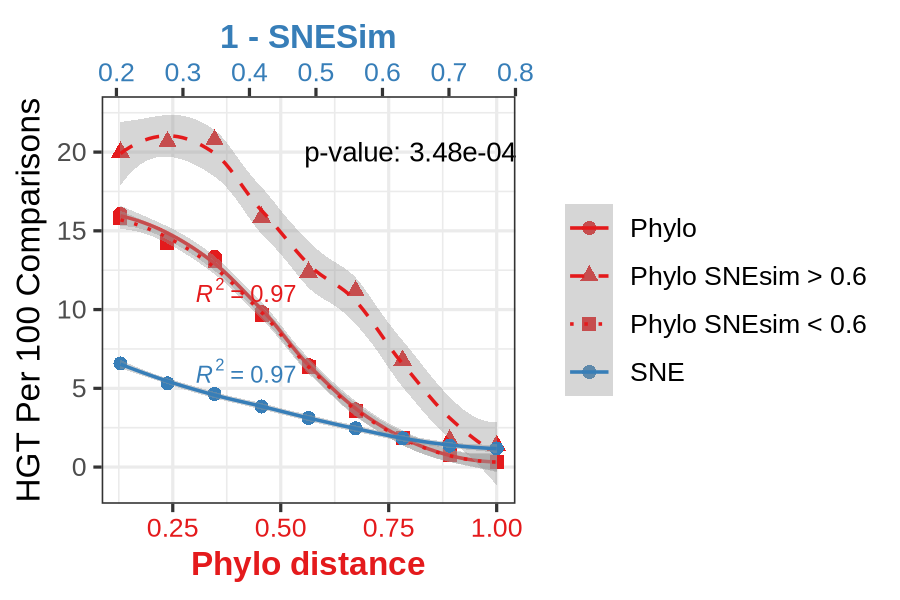

In [5]:
local({
  options(repr.plot.width = 4.5, repr.plot.height = 3, repr.plot.res = 200)
  print(p2)
})

### HGT predict

In [32]:
hgt_predict_res <- read.csv("data/hgt_predict_res_all.csv") %>% filter(group != "Cooccur")
aucprc_res <- hgt_predict_res %>%
    group_by(fold = test, group) %>%
    summarise(
        aucprc = PRROC::pr.curve(scores.class0 = proba, weights.class0 = labels)$auc.integral,
        .groups = "drop"
    )
aucprc_res$group <- dplyr::recode(aucprc_res$group, "SNE+PhyloE" = "SNE_PhyloE")
aucprc_res$group <- factor(aucprc_res$group, levels = c("SNE", "PhyloE", "SNE_PhyloE"))

line_plot <- aucprc_res %>% group_by(group) %>%
    summarise(aucprc_mean = mean(aucprc), aucprc_sd = sd(aucprc))
aucprc_res <- merge(aucprc_res, line_plot, by=c("group"))
positive_proportion <- mean(hgt_predict_res$labels)

p1 <- aucprc_res %>% ggplot(aes(x=group, y=aucprc)) +
    geom_point() +
    geom_errorbar(aes(ymin = aucprc_mean - aucprc_sd, ymax = aucprc_mean + aucprc_sd), width = 0.1) +
    geom_line(aes(group=fold, y = aucprc_mean), alpha = 0.5, linewidth = 1, linetype = "solid") +
    theme_bw(base_size = 10) +
    geom_hline(yintercept = positive_proportion,
               color = "gray",
               linetype = "dashed",
               linewidth = 1) +
    labs(x="", y="AUPRC") +
    theme(
        legend.position = "top",
        plot.title = element_text(hjust = 0.5),
    ) +
    annotate(
        "text",
        x = "SNE_PhyloE",
        y = positive_proportion,
        label = paste("Baseline:", round(positive_proportion, 3)),
        hjust = 1.1,
        vjust = -0.5,
        color = "gray40",
        size = 3.5
    )

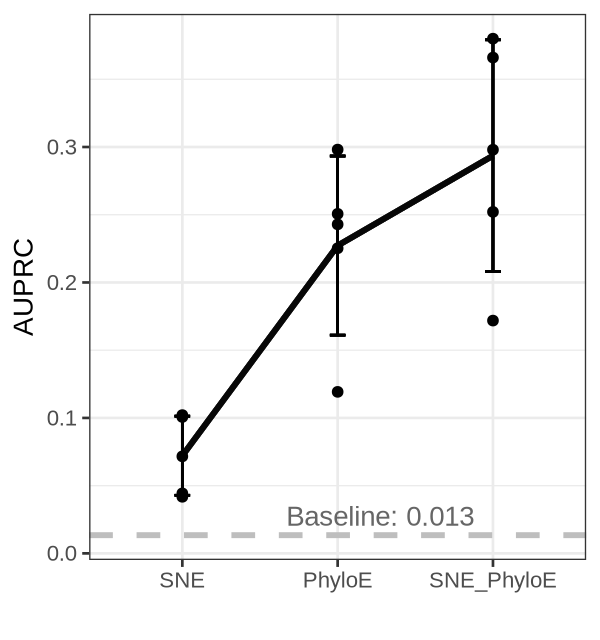

In [33]:
local({
  options(repr.plot.width = 3, repr.plot.height = 3.2, repr.plot.res = 200)
  print(p1)
})

### KO vs SNEs by Adonis2 and phylolm

#### phylolm

In [ ]:
kegg_ko <- read.csv("data/ko_pathway.tsv", sep="\t",) %>% distinct(ko_id, .keep_all = TRUE) %>% column_to_rownames("ko_id")
result_path <- "data/phylolm/"
ko_name <- read.csv("data/ko_names.txt", header=FALSE)
ko_name <- as.vector(ko_name$V1)

p_values <- vector("numeric", length = length(ko_name))
names(p_values) <- colnames(ko_name)  
LR_stat <- vector("numeric", length = length(ko_name))
names(LR_stat) <- colnames(ko_name)
converged <- vector("logical", length = length(ko_name))  

for (i in seq_along(ko_name)) {
    tryCatch({
        model_file <- paste0(result_path, "co_model_", ko_name[i], ".rds")
        null_file <- paste0(result_path, "co_null_model_", ko_name[i], ".rds")
        
        model <- readRDS(model_file)
        null_model <- readRDS(null_file)

        if (!all(c("logLik", "convergence") %in% names(model))) {
            stop("Invalid model structure")
        }
        if (model$convergence == 0 && null_model$convergence == 0) {
            LR_stat[i] <- 2 * (model$logLik - null_model$logLik)
            p_values[i] <- pchisq(LR_stat[i], df = 100, lower.tail = FALSE)
            converged[i] <- TRUE
        } else {
            p_values[i] <- NA_real_
            LR_stat[i] <- NA_real_
            converged[i] <- FALSE
        }
    }, error = function(e) {
        warning(paste("Error in pathway", pathway[i], ":", e$message))
        p_values[i] <- NA_real_
        LR_stat[i] <- NA_real_
        converged[i] <- FALSE
    })
}
valid_ko <- ko_name[!is.na(p_values) & converged]
valid_p <- p_values[!is.na(p_values) & converged]
valid_LR_stat <- LR_stat[!is.na(p_values) & converged]
convergence_rate <- mean(converged) * 100

results <- list(
    p_values = p_values,
    LR_stat = valid_LR_stat,
    converged = converged,
    valid_p = valid_p
)
q_value  <- qvalue(results$valid_p)
res <- data.frame(results$valid_p, 
                  q_value = q_value$qvalues,
                  LR_stat=results$LR_stat,
                  ko = valid_ko, ko_descript = kegg_ko[valid_ko, "ko_description"]) %>%
    arrange(desc(LR_stat))
res <- res %>% filter(q_value < 0.01) %>% arrange(desc(LR_stat))
write.csv("data/KO_phyloglm.csv")

In [17]:
res <- read.csv("data/KO_phyloglm.csv", row.names = 1)
# res <- res[1:20, ]
pick_ko <- c("K01547", "K03320", "K05846", "K14698", "K06400", "K21739", "K02038", "K18220", "K01607", "K00012")
res <- res %>% filter(ko %in% pick_ko)
# rownames(res) <- ko_names[2,]
# write.csv(res, "/home/dongbiao/word_embedding_microbiome/all_data/gut/subsystem_predict/KO_phyloglm.csv")
res$descp <- c("K01547; potassium-transporting ATPase ATP-binding subunit",
          "K03320; ammonium transporter, Amt family",
          "K05846; osmoprotectant transport system permease protein",
          "K14698; ATP-binding cassette, subfamily B, bacterial IrtA/YbtP",
          "K06400; site-specific DNA recombinase",
          "K21739; probable pyridine nucleotide-disulfide oxidoreductase",
          "K02038; phosphate transport system permease protein",
          "K18220; ribosomal protection tetracycline resistance protein",
          "K01607; 4-carboxymuconolactone decarboxylase",
          "K00012; UDPglucose 6-dehydrogenase")
res$descp <- factor(res$descp, levels = res$descp)
p2_phyloglm <- res %>% 
    ggplot(aes(x = LR_stat, y = descp)) +
    geom_bar(stat = "identity", position = "dodge", fill = "skyblue") +
    scale_y_discrete(position = "right") +  # y轴标签在右侧
    scale_x_reverse() +  # 反转x轴，使柱子从右向左生长
    theme_bw(base_size = 10) +
    labs(x = "LR_stat", y = "", title = "") +
    coord_cartesian(xlim = c(400, 200)) + 
    theme(
        axis.text.y = element_text(size = 8),
        axis.text.x = element_text(size = 10),
        plot.title = element_text(hjust = 0.5),
    )

#### Adonis2

In [ ]:
kegg_ko <- read.csv("data/ko_pathway.tsv", sep="\t",) %>% distinct(ko_id, .keep_all = TRUE) %>% column_to_rownames("ko_id")
ko_names <- read.csv("data/ko_names.txt", header = FALSE)
ko_names <- ko_names$V1
r2 <- c()
f <- c()
p <- c()
for (i in ko_names){
    res <- readRDS(paste0("data/adonis/adonis2_", i, ".rds"))
    r2 <- c(r2, res[1, 3])
    f <- c(f, res[1, 4])
    p <- c(p, res[1, 5])
}
adonis_SNE_KO <- data.frame(KO = ko_names, r2 = r2, F = f, p_value = p)
adonis_SNE_KO$description <- kegg_ko[adonis_SNE_KO$KO, "ko_description"]
write.csv(adonis_SNE_KO, "data/adonis2_res.csv", row.names=FALSE)

In [18]:
res <- read.csv("data/adonis2_res.csv", row.names = 1) %>%
    arrange(desc(F))
pick_ko <- c("K19824", "K07079", "K07699", "K03617", "K03091", "K01151", "K07138", "K10206", "K18220", "K01599")
res <- res[pick_ko, ]
res$descp <- c("K19824: rubrerythrin",
               "K07079: uncharacterized protein",
               "K07699: stage 0 sporulation protein A",
               "K03617: H+/Na+-translocating ferredoxin:NAD+ oxidoreductase subunit A",
               "K03091: RNA polymerase sigma-E/F/G factor",
               "K01151: deoxyribonuclease IV",
               "K07138: uncharacterized protein",
               "K10206: LL-diaminopimelate aminotransferase",
               "K18220: ribosomal protection tetracycline resistance protein",
               "K01599: uroporphyrinogen decarboxylase")
res$descp <- factor(res$descp, levels = res$descp)
p2_adonis <- res %>% 
    ggplot(aes(x = `F`, y = descp)) +
    geom_bar(stat = "identity", position = "dodge", fill = "skyblue") +
    scale_y_discrete(position = "right") +  
    scale_x_reverse() + 
    theme_bw(base_size = 10) +
    labs(x = "F_stat", y = "", title = "") +
    coord_cartesian(xlim = c(75, 40)) +
    theme(
        axis.text.y = element_text(size = 8),
        axis.text.x = element_text(size = 10),
        plot.title = element_text(hjust = 0.5),
    )

In [19]:
p <- plot_grid(p2_adonis, p2_phyloglm, axis = 'lr',
               align="v", nrow = 2, ncol = 1, plot=FALSE)

Warning message in as_grob.default(plot):
"Cannot convert object of class logical into a grob."


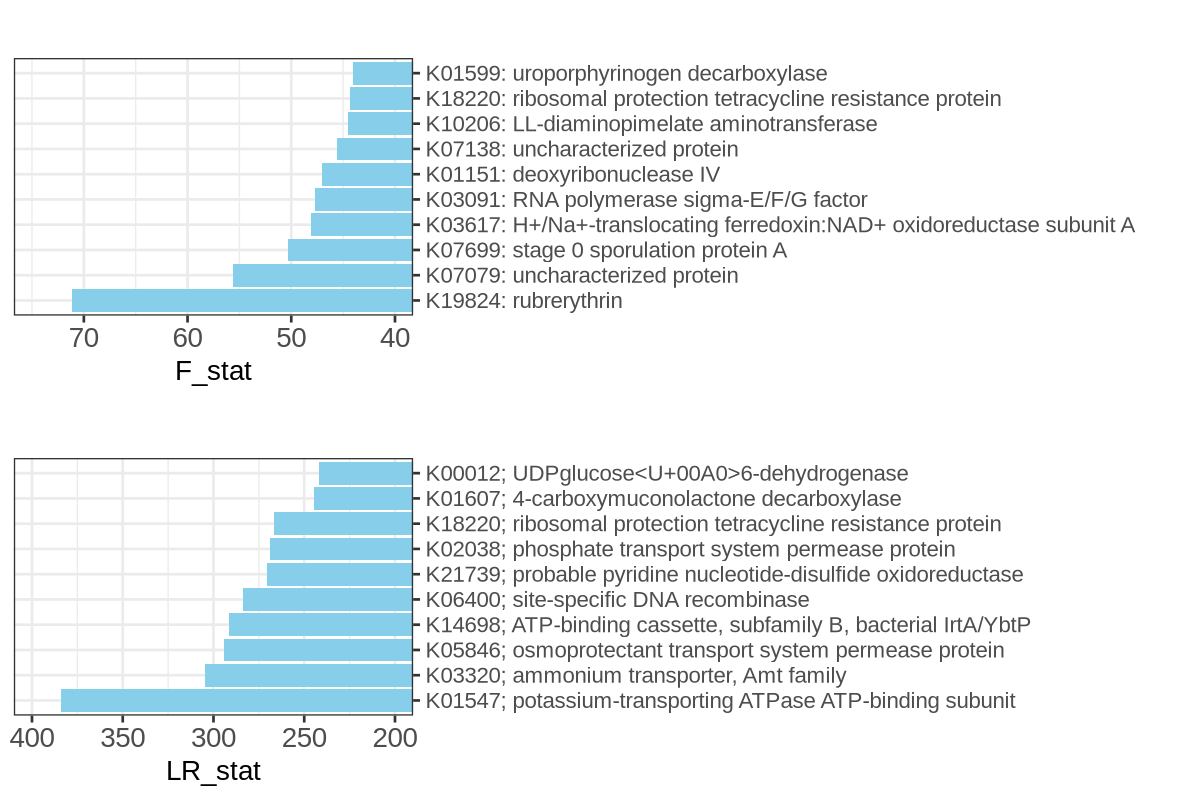

In [23]:
local({
  options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200)
  print(p)
})

### supplement results

In [34]:
hgt_predict_res <- read.csv("data/hgt_predict_res_all.csv")
aucprc_res <- hgt_predict_res %>%
    group_by(fold = test, group) %>%
    summarise(
        aucprc = PRROC::pr.curve(scores.class0 = proba, weights.class0 = labels)$auc.integral,
        .groups = "drop"
    )
aucprc_res$group <- dplyr::recode(aucprc_res$group, "SNE+PhyloE" = "SNE_PhyloE")
aucprc_res$group <- factor(aucprc_res$group,
                           levels = c("Cooccur", "SNE", "PhyloE", "SNE_PhyloE"))

positive_proportion <- mean(hgt_predict_res$labels)

p1 <- aucprc_res %>% ggplot(aes(x = group, y = aucprc)) +
    geom_boxplot(outlier.shape = NA, width = 0.6) +
    geom_jitter(width = 0.15, size = 1.5, alpha = 0.7) +
    geom_hline(yintercept = positive_proportion,
               color = "gray", linetype = "dashed", linewidth = 1) +
    theme_bw(base_size = 10) +
    labs(x = "", y = "AUPRC") +
    theme(
        legend.position = "top",
        plot.title = element_text(hjust = 0.5),
    ) +
    annotate(
        "text",
        x = "SNE_PhyloE",
        y = positive_proportion,
        label = paste("Baseline:", round(positive_proportion, 3)),
        hjust = 1.1, vjust = -0.5, color = "gray40", size = 3.5
    )

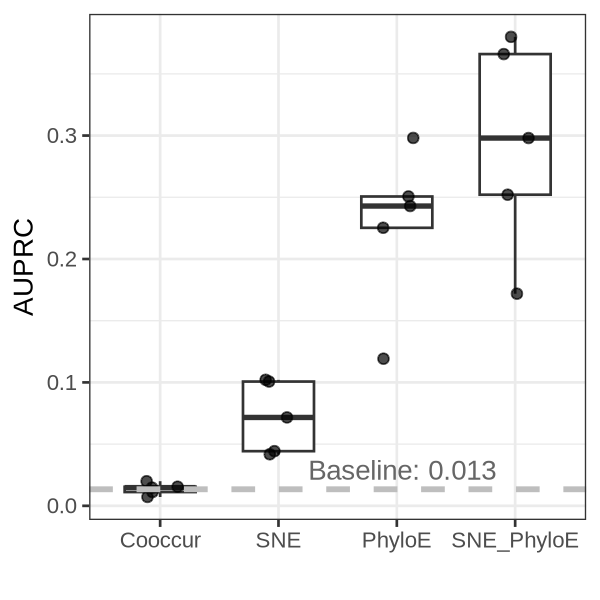

In [37]:
local({
  options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 200)
  print(p1)
})